Imports set up

In [25]:
# necessary imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the pre-processed csv file

In [6]:
#processed_csv_path = "datasets/processed/mental_health_preprocessed.csv"
processed_csv_path = "/content/drive/MyDrive/mental_health_preprocessed.csv"
df = pd.read_csv(processed_csv_path, keep_default_na=False, na_values=[])

print(f"Loaded {len(df):,} rows")
print("Columns:", list(df.columns))
df.head()

Loaded 67,770 rows
Columns: ['text', 'clean_text', 'label', 'source']


,text,clean_text,label,source
0,a question about the third conditional. i was ...,question third conditional making questions st...,None,Murarka
1,the epitome of my life i've recently requested...,epitome life recently requested testing accomm...,ADHD,Murarka
2,what are your favourites offbeat destinations ...,favourites offbeat destinations asia list camb...,None,Murarka
3,synesthesia survey (what colour is each month ...,synesthesia survey colour month synesthesia sy...,None,Murarka
4,"science ama series: i’m phil baran, and i’m he...",science ama series phil baran talk work baran ...,None,Murarka


## Define the features (X) and labels (Y)

In [7]:
X = df['clean_text']
y = df['label']

In [8]:
# first split into the full data into train/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, stratify=y)

# then split a second time the training data into train/validation (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, train_size=0.8, stratify=y_train)

print(f"Train size: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test size: {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")
print(f"Validation size: {len(X_val):,} ({len(X_val)/len(df)*100:.1f}%)")

Train size: 43,372 (64.0%)
Test size: 13,554 (20.0%)
Validation size: 10,844 (16.0%)


## TD_IDF Pipeline: turn features into a tokenized matrix

In [9]:
# create a TfidfVectorizer object to convert post text into numeric vectors
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,2))

# call .fit_transform() on the training text only
X_train_tokenized = vectorizer.fit_transform(X_train)

# then call .transform() on val and test
X_val_tokenized =  vectorizer.transform(X_val)
X_test_tokenized =  vectorizer.transform(X_test)


## Label encoding

In [10]:
# create a label encoder object
le = LabelEncoder()

# call .fit_transform() on the training text only
y_train_encoded = le.fit_transform(y_train)

# then call .transform() on val and test
y_val_encoded =  le.transform(y_val)
y_test_encoded =  le.transform(y_test)


In [ ]:
# To do: Week 2 tasks

## Logistic regression

In [13]:
# create a lr object
lr = LogisticRegression(class_weight='balanced', max_iter=1000)

# fit it to the data: train the model with X_train_tokenized and y_train_encoded
lr.fit(X_train_tokenized, y_train_encoded)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [18]:
# run prediction on validation set (not on test yet)
predictions_val = lr.predict(X_val_tokenized)

In [21]:
# read predictions (just for some snity check)
y_actual = le.inverse_transform(y_val_encoded)
y_pred = le.inverse_transform(predictions_val)
pd.DataFrame({'actual': y_actual, 'predicted': y_pred})

,actual,predicted
0,Depression,Depression
1,Depression,Bipolar
2,Depression,Depression
3,Depression,Depression
4,None,None
...,...,...
10839,Depression,Depression
10840,Depression,Depression
10841,Depression,Depression
10842,Depression,Depression


## Evaluation : classification report

In [23]:
target_names = le.classes_
print(classification_report(y_actual, y_pred, target_names=target_names))

              precision    recall  f1-score   support

        ADHD       0.69      0.84      0.76       474
     Anxiety       0.68      0.79      0.73      1046
     Bipolar       0.70      0.75      0.72       864
  Depression       0.91      0.80      0.85      4588
        None       0.84      0.86      0.85      3473
        PTSD       0.62      0.82      0.70       399

    accuracy                           0.82     10844
   macro avg       0.74      0.81      0.77     10844
weighted avg       0.83      0.82      0.82     10844



## Logistic regression baseline Results:

Our baseline Logistic Regression model achieved an overall accuracy of 82% and a macro F1 score of 0.77 across our 6 mental health classes.

Key observations:
- Depression and None performed best (F1: 0.85): likely due to having the most training samples (4,588 and 3,473 respectively)
- PTSD and Anxiety performed worst (F1: 0.70 and 0.73): both have significantly fewer samples (399 and 1,046)
- That suggests that class imbalance is still affecting our performance (even though we used class_weight='balanced')
- Macro F1 of 0.77 is our benchmark score, the future models (like a neural network) will need to beat this score

The confusion matrix below shows which classes the model confuses most often

## Confusion matrix

In [27]:
conf_matrix = confusion_matrix(y_actual, y_pred)
print(conf_matrix)

[[ 397   12   24   11   27    3]
 [  21  830   31   63   82   19]
 [  18   40  648   81   51   26]
 [  78  199  172 3649  408   82]
 [  56  123   49  182 2990   73]
 [   2   19    8   28   15  327]]


<Axes: >

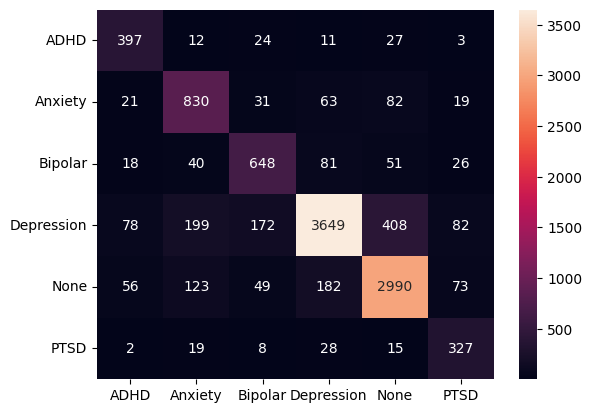

In [29]:
# Visualizing the confusion matrix for easy read

sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names)